In [1]:
import numpy as np
import evaluate
from datasets import DatasetDict, Audio, ClassLabel, load_dataset
from transformers import (
    AutoFeatureExtractor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
id2label = {0: "other", 1: "drone"}
label2id = {"other": 0, "drone": 1}


/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id = "facebook/wav2vec2-base"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)

def preprocess_function(examples):
    """
    Preprocesses the audio batches.
    Input structure: List(List(List(float64))) -> [Batch, Channels, Time]
    """
    audio_arrays = []

    for audio_list in examples['audio']:
        # 1. Convert to numpy array
        # Shape usually becomes (Channels, Time) or just (Time,)
        arr = np.array([x for x in audio_list])

        # 2. Handle Multi-channel audio
        # If 2D (e.g., Stereo), average channels to convert to Mono
        if arr.ndim > 1:
            arr = np.mean(arr, axis=0)

        audio_arrays.append(arr)

    # 3. Feature Extraction: Padding/Truncation & Log-Mel Spectrogram (internal)
    # We target a max length of 5 seconds (5 * 16000 = 80000 samples)
    # Adjust 'max_length' based on your drone audio typical duration
    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=16000,
        padding=True,
        truncation=True,
        max_length=16000 * 5
    )

    inputs['label'] = examples['label']
    return inputs

/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


In [3]:
dataset = load_dataset("Hibou-Foundation/big_ds_4_raw_wav_balanced")

In [4]:
# dataset = dataset.with_format("torch", columns=["audio", "label"])

print("\nDataset splits:")
print({k: v.shape for k, v in dataset.items()})

print("\nDataset features:")
print(dataset["train"].features)
# print(dataset["train"][0]["audio"].shape)


Dataset splits:
{'train': (352116, 2), 'val': (43580, 2), 'test': (43478, 2)}

Dataset features:
{'audio': List(Value('float32')), 'label': ClassLabel(names=['other', 'drone'])}


In [5]:
dataset = DatasetDict({
    split: ds.select(range(int(0.01 * len(ds))))
    for split, ds in dataset.items()
})
print({k: v.shape for k, v in dataset.items()})

{'train': (3521, 2), 'val': (435, 2), 'test': (434, 2)}


In [6]:
encoded_splits = dataset.map(
    preprocess_function,
    remove_columns=["audio"],
    batched=True,
    batch_size=32,
    num_proc=20
)

In [7]:
# Load the pre-trained model with a classification head
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_id,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# Freeze the feature encoder for faster initial training (optional but recommended)
# Comment this out if massive compute resources and want to fine-tune everything
model.freeze_feature_encoder()

In [9]:
# ==========================================
# 4. Metrics and Training
# ==========================================
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=eval_pred.label_ids)

training_args = TrainingArguments(
    output_dir="./drone_detector",

    do_train=True,
    do_eval=True,

    eval_strategy="steps",   # REQUIRED PLACEHOLDER for old versions
    logging_steps=20,
    logging_first_step=True,

    save_steps=500,
    eval_steps=500,

    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    warmup_steps=500,
    fp16=torch.cuda.is_available(),
    report_to=[]
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_splits["train"],
    eval_dataset=encoded_splits["val"],
    tokenizer=feature_extractor,
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_81628/1758022163.py:38: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [10]:
print("Starting training...")
trainer.train()

print("Evaluating on Test Set...")
test_results = trainer.evaluate(encoded_splits["test"])
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")

Starting training...


/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Step,Training Loss,Validation Loss,Accuracy
500,0.337200,0.344409,0.859770


/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Evaluating on Test Set...


Test Accuracy: 0.8641


In [11]:
# Get predictions on test set for detailed evaluation
print("Getting predictions on test set...")
test_predictions = trainer.predict(encoded_splits["test"])

# Extract predictions and labels
y_pred = np.argmax(test_predictions.predictions, axis=1)
y_true = test_predictions.label_ids
y_probs = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()

print(f"Test set size: {len(y_true)}")
print(f"Predictions shape: {y_pred.shape}")
print(f"Labels shape: {y_true.shape}")


Getting predictions on test set...
Test set size: 434
Predictions shape: (434,)
Labels shape: (434,)


In [12]:
# Compute detailed metrics
test_accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("=" * 60)
print("Test Set Evaluation Metrics")
print("=" * 60)
print(f"Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("=" * 60)


Test Set Evaluation Metrics
Accuracy:  0.8641 (86.41%)
Precision: 0.8883
Recall:    0.8641
F1-Score:  0.8612


In [13]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["other", "drone"], digits=4))



Classification Report:
              precision    recall  f1-score   support

       other     0.7957    0.9911    0.8827       224
       drone     0.9871    0.7286    0.8384       210

    accuracy                         0.8641       434
   macro avg     0.8914    0.8598    0.8605       434
weighted avg     0.8883    0.8641    0.8612       434



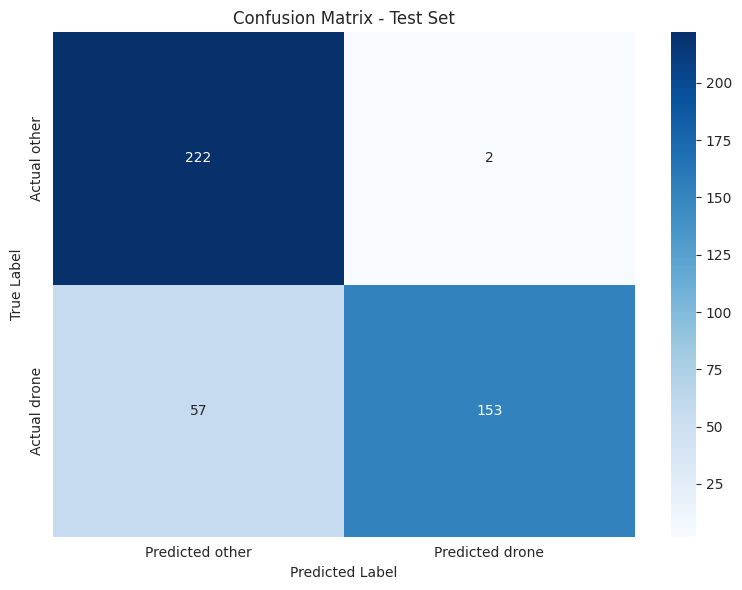


Confusion Matrix:
True Negatives (TN): 222
False Positives (FP): 2
False Negatives (FN): 57
True Positives (TP): 153


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Predicted other", "Predicted drone"],
    yticklabels=["Actual other", "Actual drone"]
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

# Print confusion matrix values
print("\nConfusion Matrix:")
print(f"True Negatives (TN): {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP): {cm[1, 1]}")


In [15]:
# Per-class metrics using sklearn
precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

tn, fp, fn, tp = cm.ravel()

print("\nPer-Class Metrics:")
print("-" * 60)
print(f"Class 'other' (0):")
print(f"  Precision: {precision_per_class[0]:.4f}")
print(f"  Recall:    {recall_per_class[0]:.4f}")
print(f"  F1-Score:  {f1_per_class[0]:.4f}")
print(f"  Support:   {tn + fp}")
print(f"\nClass 'drone' (1):")
print(f"  Precision: {precision_per_class[1]:.4f}")
print(f"  Recall:    {recall_per_class[1]:.4f}")
print(f"  F1-Score:  {f1_per_class[1]:.4f}")
print(f"  Support:   {tp + fn}")
print("-" * 60)



Per-Class Metrics:
------------------------------------------------------------
Class 'other' (0):
  Precision: 0.7957
  Recall:    0.9911
  F1-Score:  0.8827
  Support:   224

Class 'drone' (1):
  Precision: 0.9871
  Recall:    0.7286
  F1-Score:  0.8384
  Support:   210
------------------------------------------------------------


In [16]:
# Load additional test datasets
print("Loading Hibou-Foundation/drone_all_test_datasets...")
ds_all_tests = load_dataset("Hibou-Foundation/drone_all_test_datasets")

# Extract different test splits
ds_test_1 = ds_all_tests["drone_test"]
ds_test_2 = ds_all_tests["drone_test_2"]
ds_parabole_1 = ds_all_tests["mic_parabole"]
ds_parabole_2 = ds_all_tests["parabole2"]

print(f"\nTest dataset sizes:")
print(f"  drone_test: {len(ds_test_1)}")
print(f"  drone_test_2: {len(ds_test_2)}")
print(f"  mic_parabole: {len(ds_parabole_1)}")
print(f"  parabole2: {len(ds_parabole_2)}")

# Check audio format
print(f"\nAudio feature type: {ds_test_1.features['audio']}")
print(f"Sample audio type: {type(ds_test_1[0]['audio'])}")
if isinstance(ds_test_1[0]['audio'], dict):
    print(f"Audio keys: {ds_test_1[0]['audio'].keys()}")
    print(f"Audio array shape: {np.array(ds_test_1[0]['audio']['array']).shape}")


Loading Hibou-Foundation/drone_all_test_datasets...

Test dataset sizes:
  drone_test: 893
  drone_test_2: 2805
  mic_parabole: 123
  parabole2: 85

Audio feature type: Audio(sampling_rate=16000, decode=True, stream_index=None)
Sample audio type: <class 'datasets.features._torchcodec.AudioDecoder'>


In [17]:
def preprocess_single(example):
    """Process a single example"""
    audio_item = example['audio']
    arr = audio_item['array']

    # Ensure it's a numpy array
    if not isinstance(arr, np.ndarray):
        arr = np.array(arr)

    # Handle multi-channel audio: convert to mono by averaging channels
    if arr.ndim > 1:
        arr = np.mean(arr, axis=0)

    # Ensure it's 1D (squeeze any extra dimensions)
    arr = np.squeeze(arr)

    # Ensure it's 1D array (not scalar)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    elif arr.ndim > 1:
        # Flatten if still multi-dimensional
        arr = arr.flatten()

    # Feature extraction
    inputs = feature_extractor(
        arr,
        sampling_rate=16000,
        padding=True    ,
        truncation=True,
        max_length=16000 * 5
    )

    inputs['label'] = example['label']
    inputs["input_values"] = inputs["input_values"][0]
    return inputs

encoded_test_1 = ds_test_1.map(
    preprocess_single,
    remove_columns=["audio"],
    batched=False,
    num_proc=1
)

encoded_test_2 = ds_test_2.map(
    preprocess_single,
    remove_columns=["audio"],
    batched=False,
    num_proc=1
)

encoded_parabole_1 = ds_parabole_1.map(
    preprocess_single,
    remove_columns=["audio"],
    batched=False,
    num_proc=1
)

encoded_parabole_2 = ds_parabole_2.map(
    preprocess_single,
    remove_columns=["audio"],
    batched=False,
    num_proc=1
)

In [18]:
print(encoded_test_1[0])

{'label': 1, 'input_values': [0.27293896675109863, 0.6574892401695251, -0.010078901425004005, 0.31880977749824524, 1.5882371664047241, 0.9780746102333069, -0.3602330684661865, 0.08211681246757507, 0.5024415850639343, -0.4679419696331024, -0.32472071051597595, 1.0991159677505493, 0.8925790786743164, 0.06614135950803757, -0.9280213117599487, -1.395755648612976, -0.8269866704940796, -0.43977826833724976, 0.9258502125740051, 1.039648175239563, -0.8299862146377563, -1.9646610021591187, -2.1644253730773926, -1.729812502861023, 0.024746941402554512, 0.015141816809773445, -0.15903007984161377, -0.16161014139652252, -1.1890133619308472, -1.4006847143173218, -1.7613695859909058, -1.7676472663879395, -2.020045757293701, -1.7975549697875977, -1.4897888898849487, -0.5898683071136475, 0.9808565378189087, -0.17511948943138123, -0.5418039560317993, -0.6792342066764832, -1.6754913330078125, -0.7440118789672852, -0.7399915456771851, 0.21520650386810303, 1.108134388923645, 0.8767940998077393, 0.848391890

In [19]:
# Get predictions on all test datasets
from tqdm import tqdm

print("Evaluating on all test datasets...")

test_datasets = {
    "drone_test": encoded_test_1,
    "drone_test_2": encoded_test_2,
    "mic_parabole": encoded_parabole_1,
    "parabole2": encoded_parabole_2
}

all_predictions = {}
all_labels = {}

for name, dataset in test_datasets.items():
    print(f"\nEvaluating {name}...")
    predictions = trainer.predict(dataset)
    all_predictions[name] = np.argmax(predictions.predictions, axis=1)
    all_labels[name] = predictions.label_ids
    print(f"  Size: {len(all_labels[name])}")
    print(f"  Done!")


Evaluating on all test datasets...

Evaluating drone_test...


  Size: 893
  Done!

Evaluating drone_test_2...


  Size: 2805
  Done!

Evaluating mic_parabole...


  Size: 123
  Done!

Evaluating parabole2...


  Size: 85
  Done!


In [20]:
# Compute metrics for each test dataset
def compute_metrics(y_true, y_pred):
    """Compute comprehensive metrics for a dataset."""
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
    }

metrics_dict = {}
for name in test_datasets.keys():
    metrics_dict[name] = compute_metrics(all_labels[name], all_predictions[name])
    print(f"\n{name} Metrics:")
    print(f"  Accuracy:  {metrics_dict[name]['accuracy']:.4f} ({metrics_dict[name]['accuracy']*100:.2f}%)")
    print(f"  Precision: {metrics_dict[name]['precision']:.4f}")
    print(f"  Recall:    {metrics_dict[name]['recall']:.4f}")
    print(f"  F1-Score:  {metrics_dict[name]['f1']:.4f}")



drone_test Metrics:
  Accuracy:  0.6069 (60.69%)
  Precision: 0.7674
  Recall:    0.6069
  F1-Score:  0.4919

drone_test_2 Metrics:
  Accuracy:  0.0531 (5.31%)
  Precision: 0.9996
  Recall:    0.0531
  F1-Score:  0.1002

mic_parabole Metrics:
  Accuracy:  0.3659 (36.59%)
  Precision: 0.1338
  Recall:    0.3659
  F1-Score:  0.1960

parabole2 Metrics:
  Accuracy:  0.3059 (30.59%)
  Precision: 0.0936
  Recall:    0.3059
  F1-Score:  0.1433


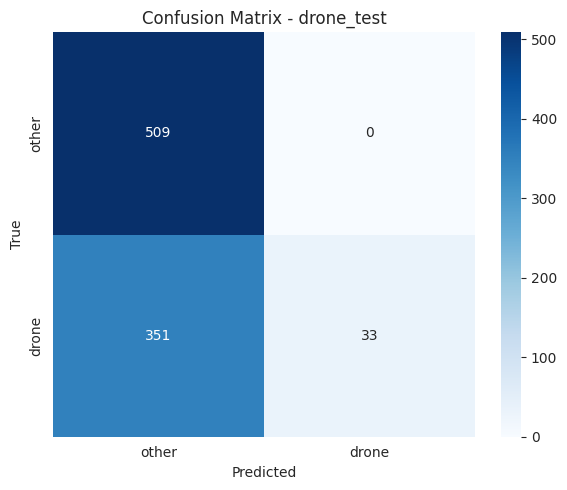

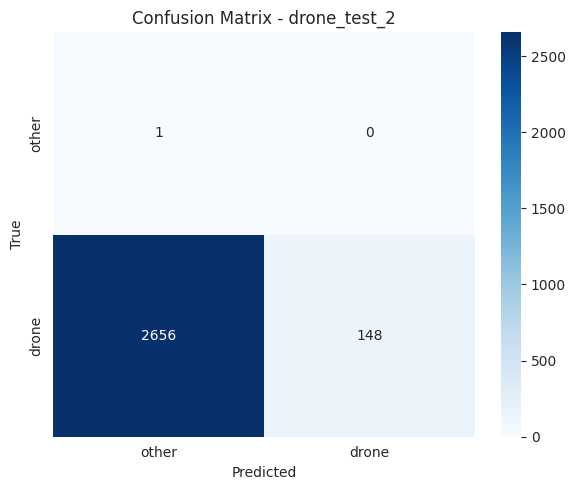

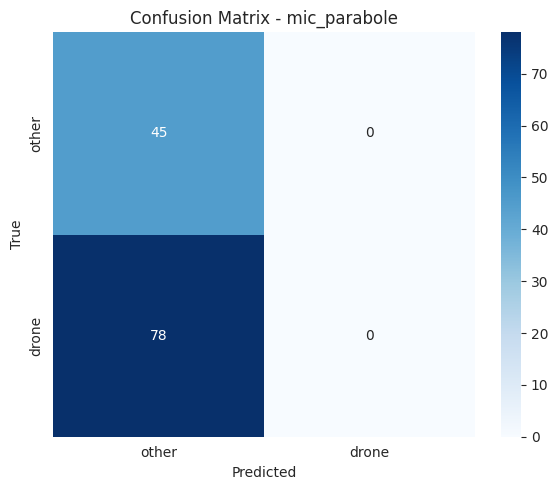

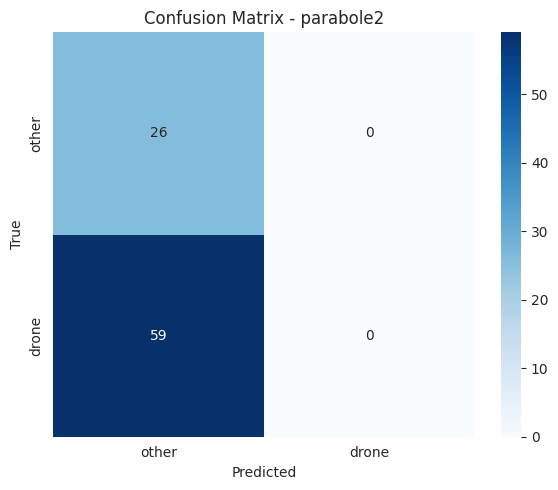

In [21]:
# Plot confusion matrices for all test datasets
CLASS_NAMES = ["other", "drone"]

def plot_confusion(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot confusion matrices
for name in test_datasets.keys():
    plot_confusion(metrics_dict[name]["confusion_matrix"], f"Confusion Matrix - {name}")


In [22]:
# Detailed classification reports for each dataset
for name in test_datasets.keys():
    print(f"\n{'='*60}")
    print(f"Classification Report - {name}")
    print('='*60)
    print(classification_report(
        all_labels[name],
        all_predictions[name],
        target_names=CLASS_NAMES,
        digits=4
    ))



Classification Report - drone_test
              precision    recall  f1-score   support

       other     0.5919    1.0000    0.7436       509
       drone     1.0000    0.0859    0.1583       384

    accuracy                         0.6069       893
   macro avg     0.7959    0.5430    0.4509       893
weighted avg     0.7674    0.6069    0.4919       893


Classification Report - drone_test_2
              precision    recall  f1-score   support

       other     0.0004    1.0000    0.0008         1
       drone     1.0000    0.0528    0.1003      2804

    accuracy                         0.0531      2805
   macro avg     0.5002    0.5264    0.0505      2805
weighted avg     0.9996    0.0531    0.1002      2805


Classification Report - mic_parabole
              precision    recall  f1-score   support

       other     0.3659    1.0000    0.5357        45
       drone     0.0000    0.0000    0.0000        78

    accuracy                         0.3659       123
   macro avg    

/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pierre/Documents/Projects/PST4/AI/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p